## Analyze inter-cluster angles

In [1]:
from pathlib import Path
from tqdm import tqdm
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import pandas as pd
import numpy as np
import concurrent.futures
import sys
import os

# 
project_workdir = Path("/home/woodydrylab/DiskArray/b05b01002/project_umap_re/")
path_param_sets = project_workdir / "outputs/UMAP/param_table.csv"
path_param_sets_highe = project_workdir / "outputs/UMAP-high-epochs/param_table.csv"
path_seed_list = project_workdir / "outputs/UMAP/seeds.txt"

# class holding file paths
class PathFactory:
    def __init__(self, base):
        self._templates = {
            "ica": base / "outputs/InterClusterAngle/{sample}/seed{seed}.csv",
            "cluster": base / "outputs/Seurat/{sample}/clusters.csv",
            "pca": base / "outputs/Seurat/{sample}/pca.csv",
            "embeddings": base / "outputs/UMAP/{sample}/seed{seed}/param_set{param_set}.csv",
            "embeddings_hepochs": base / "outputs/UMAP-high-epochs/{sample}/seed{seed}/param_set{param_set}.csv",
            "ica_aligned": base / (
                "outputs/InterClusterAngle/{sample}/per_{n}_embeddings/param_set{param_set}_median.csv"
            ),
            "ica_high_epochs": base / "outputs/InterClusterAngle/{sample}/high_epochs/seed{seed}.csv",
            "aligned_rmsd": base / (
                "outputs/AlignEmbeddings/procrustes_alignment/{sample}/"
                "per_{n}_embeddings/param_set{param_set}/batch_{batch}/mean_rmsd.csv"
            ),
            "aligned_embeddings": base / (
                "outputs/AlignEmbeddings/procrustes_alignment/{sample}/"
                "per_{n}_embeddings/param_set{param_set}/batch_{batch}/aligned_embeddings.csv"
            ),
            "outdir": base / "notebooks/inter-cluster-angle/temp/results_20260225/"
        }

    @staticmethod
    def path_maker(template, **kwargs):
        template = str(template)
        for k, v in kwargs.items():
            template = template.replace("{"+ k +"}", str(v))
        return Path(template)

    def __getattr__(self, name):
        template = self._templates[name]
        return lambda **kwargs: PathFactory.path_maker(template, **kwargs)

paths = PathFactory(project_workdir)

### Define util functions

In [3]:
def get_param_set(param_set_df, **kwargs):
    query_string = " & ".join(
        [f"({k} == {v!r})" for k, v in kwargs.items()]
    )
    return param_set_df.query(query_string).index.to_list() 

### Get or set sample names (from command line or manually define)

In [4]:
if not 'ipykernel' in sys.modules:
    samples = sys.argv[1:]
else:    
    # samples = ["ath", "gar", "lch", "osa", "ptr", "tma", "zma"]
    samples = ["ath", "gar", "lch", "osa", "ptr", "tma", "zma"]

print("[Python] Running samples =", samples)

[Python] Running samples = ['ath', 'gar', 'lch', 'osa', 'ptr', 'tma', 'zma']


### Create output directory

In [5]:
os.makedirs(paths.outdir(), exist_ok=True)
print(paths.outdir())

/home/woodydrylab/DiskArray/b05b01002/project_umap_re/notebooks/inter-cluster-angle/temp/results_20260225


### Read data

#### 1. UMAP seeds

In [6]:
seeds = [l.strip() for l in open(path_seed_list, "r")]
len(seeds)

1000

#### 2. Parameter sets

In [7]:
param_sets = pd.read_csv(path_param_sets, index_col = 0)
param_sets.describe()

,n_neighbors,min_dist,n_epochs
count,360.000000,360.000000,360.000000
mean,78.000000,0.448333,375.000000
std,68.035711,0.357354,238.816721
min,10.000000,0.000000,100.000000
25%,30.000000,0.100000,175.000000
50%,50.000000,0.400000,350.000000
75%,100.000000,0.800000,550.000000
max,200.000000,0.990000,700.000000


In [8]:
param_sets_highe = pd.read_csv(path_param_sets_highe, index_col = 0)
param_sets_highe.describe()

,n_neighbors,min_dist,n_epochs
count,90.000000,90.000000,90.0
mean,78.000000,0.448333,10000.0
std,68.321777,0.358857,0.0
min,10.000000,0.000000,10000.0
25%,30.000000,0.100000,10000.0
50%,50.000000,0.400000,10000.0
75%,100.000000,0.800000,10000.0
max,200.000000,0.990000,10000.0


#### 3. Cluster dfs

In [9]:
cluster_dfs = {
    sample: pd.read_csv(
        paths.cluster(sample=sample),
        index_col=0,
        dtype=str,
        header=0,
        names=["cluster"] # overwrite existing headers
    ) for sample in samples
}
cluster_dfs[samples[0]]

,cluster
AAACCCAAGAGCCATG,9
AAACCCAAGCTGAAGC,7
AAACCCAAGGAAGAAC,0
AAACCCAAGGGAGAAT,6
AAACCCAAGGGTGAGG,4
...,...
TTTGTTGTCACCGGGT,10
TTTGTTGTCACCTGGG,7
TTTGTTGTCCTGGTCT,5
TTTGTTGTCGCGTGAC,1


#### 4. Inter-cluster angle

In [10]:
def stat_inter_cluster_angles(df: pd.DataFrame) -> pd.DataFrame:
    """
    Docstring explaining the function's purpose.

    Args:
        parameter_name (type): Description of the argument.
        df (pd.DataFrame): 
            A dataframe with columns:
            param_set, seed, vertex, cluster_a, cluster_b, cos_similarity

    Returns:
        pd.DataFrame:
            A dataframe with columns:
            param_set, vertex, cluster_a, cluster_b, degree_max, degree_min, seed_max, seed_min
    """
    # convert consine
    df["degree"] = df["cos_similarity"].apply(lambda x: np.degrees(np.arccos(x)))
    g_df = df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])

    # find max & min degree and the corresponding seeds; the iqr and sd of the degree
    ica_max_min = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            iqr_degree=("degree", iqr),
            degree_sd=("degree", "std")
        )
        .assign(
            max_degree_seed=df.loc[
                g_df["degree"].idxmax().values, "seed"
            ].values,
            min_degree_seed=df.loc[
                g_df["degree"].idxmin().values, "seed"
            ].values,
        )
    )

    # calculate differece between max and min degree
    ica_max_min["delta_max_min"] = ica_max_min.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    
    # 
    ica_max_min["sample"] = sample
    return ica_max_min

In [11]:
ica_dfs = {}
for sample in samples:
    with concurrent.futures.ProcessPoolExecutor(max_workers=48) as executor:
        print(f"sample={sample}", end="")
        # submit jobs to pool
        futures = [
            executor.submit(pd.read_csv, paths.ica(sample=sample, seed=seed)) 
            for seed in seeds
        ]

        # store concurrent results to list
        df_list = []
        for fut in tqdm(
            concurrent.futures.as_completed(futures),
            total=len(futures)
        ):
            df_temp = fut.result()
            mask1 = df_temp["vertex"] < 8
            mask2 = df_temp["cluster_a"] < 8
            mask3 = df_temp["cluster_b"] < 8
            df_temp = df_temp[mask1 & mask2 & mask3]
            df_list.append(df_temp)

        # concat dataframe and map to dict for named access
        print("Concat...")
        ica_dfs[sample] = pd.concat(df_list, ignore_index=True)

        del df_list

sample=ath

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [03:47<00:00,  4.40it/s]


Concat...
sample=gar

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:00<00:00,  8.30it/s]


Concat...
sample=lch

...

Concat...
sample=tma

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:31<00:00,  6.62it/s]


Concat...
sample=zma

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:18<00:00, 54.66it/s]


Concat...


_**Use only results of the first 8 clusters**_

In [12]:
for sample, ica_df in ica_dfs.items():
    print(sample, ica_dfs[sample].shape)

ath (60480000, 6)
gar (60480000, 6)
lch (60480000, 6)
osa (60480000, 6)
ptr (60480000, 6)
tma (60480000, 6)
zma (60480000, 6)


_**Convert cosine similarity to degree**_

In [13]:
for sample, ica_df in ica_dfs.items():
    ica_df["radian"] = ica_df["cos_similarity"].apply(np.arccos)
    ica_df["degree"] = ica_df["radian"].apply(np.degrees)
    ica_df.drop(columns=["cos_similarity", "radian"])

### Stats per parameter sets per cluster combinations for the followings:  
- SD
- max/min degree (and corresponding seeds)
- max degree difference

In [14]:
stat_df = pd.DataFrame()
for sample, ica_df in ica_dfs.items():
    g_df = ica_df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])
    foo = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            degree_sd=("degree", "std")
        )
        .assign(
            max_degree_seed=ica_df.loc[
                g_df["degree"].idxmax().values, "seed"
            ].values,
            min_degree_seed=ica_df.loc[
                g_df["degree"].idxmin().values, "seed"
            ].values,
        )
    )
    foo["delta_max_min"] = foo.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    foo = pd.merge(foo, param_sets, left_index=True, right_index=True, how="left")
    foo["sample"] = sample
    stat_df = pd.concat([stat_df, foo])
stat_df = stat_df.reset_index()

In [15]:
stat_df.head()

,param_set,vertex,cluster_a,cluster_b,max_degree,min_degree,degree_sd,max_degree_seed,min_degree_seed,delta_max_min,n_neighbors,min_dist,metric,n_epochs,sample
0,0,0,1,2,36.232564,0.069192,10.225038,73464,10851,36.163372,10,0.0,euclidean,100,ath
1,0,0,1,3,27.942882,0.003392,6.115227,66207,83385,27.939490,10,0.0,euclidean,100,ath
2,0,0,1,4,29.958105,0.012542,5.378503,42325,53279,29.945562,10,0.0,euclidean,100,ath
3,0,0,1,5,46.401134,0.042610,10.155650,30028,87236,46.358523,10,0.0,euclidean,100,ath
4,0,0,1,6,61.184231,2.635450,10.090987,13617,52600,58.548780,10,0.0,euclidean,100,ath


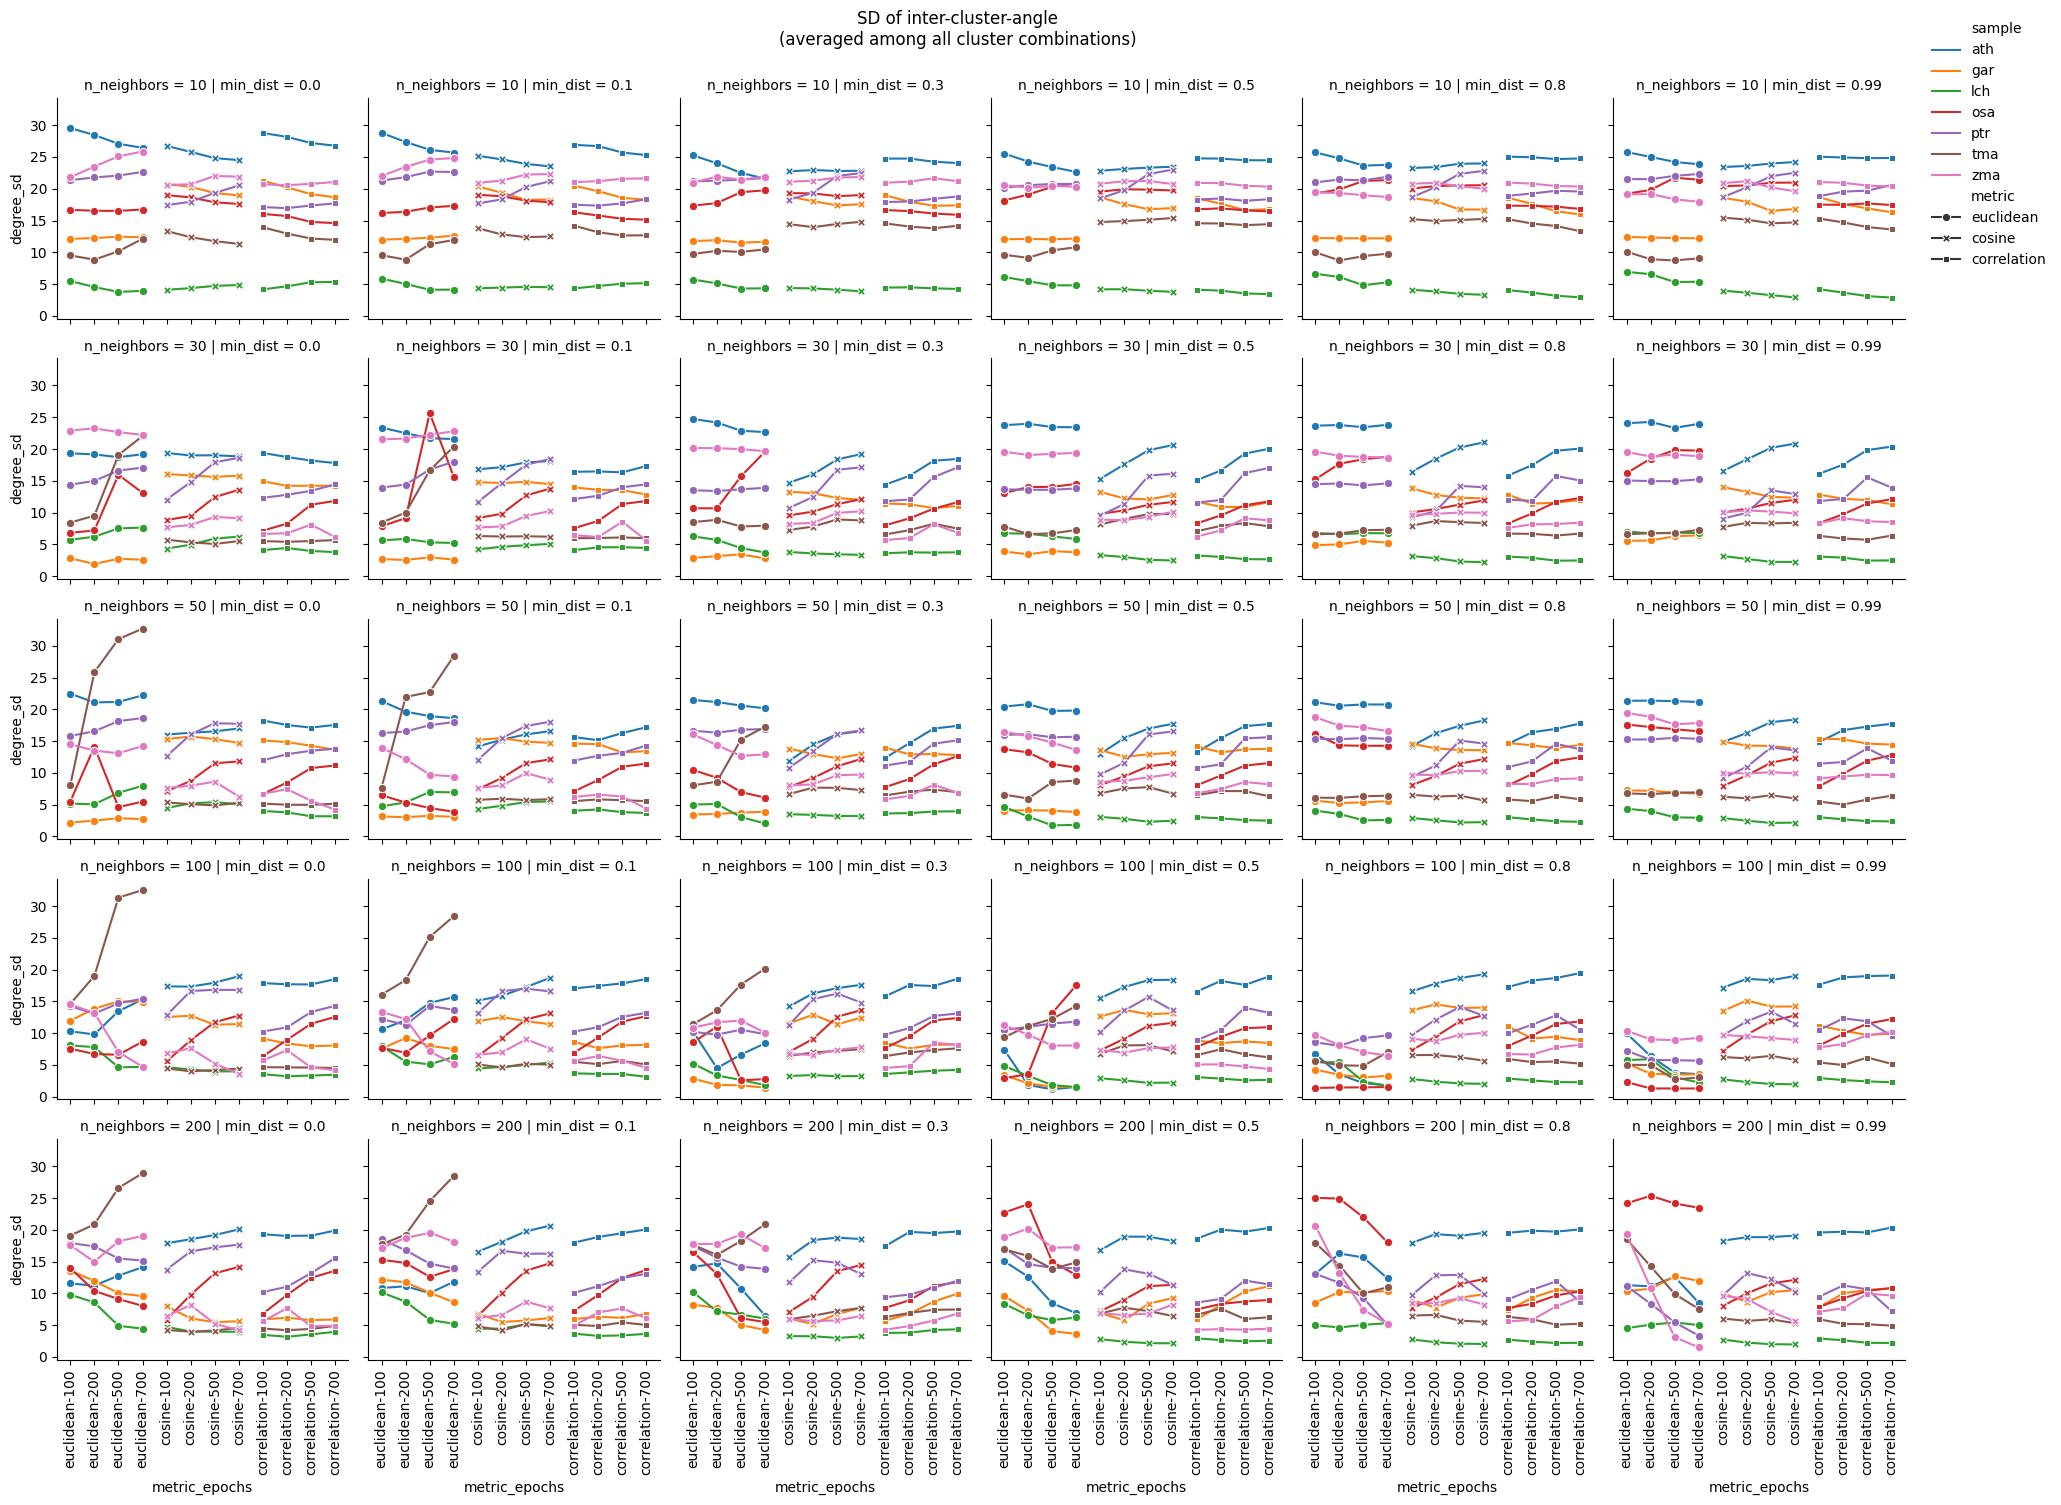

In [16]:
# data = stat_df.groupby(["n_neighbors", "min_dist", "metric", "n_epochs", "sample"]).mean().reset_index()
data = stat_df.copy()
data["metric_epochs"] = data.apply(lambda x: f"{x.metric}-{x.n_epochs}", axis=1)
g = sns.FacetGrid(
    data,
    row="n_neighbors",
    col="min_dist",
)
g.map_dataframe(
    sns.lineplot,
    x="metric_epochs",
    y="degree_sd",
    hue="sample",
    style="metric",
    palette="tab10",
    err_style=None,
    dashes=False,
    markers=True
)
g.tick_params(axis="x", rotation=90)
g.add_legend()
g.fig.suptitle("SD of inter-cluster-angle\n(averaged among all cluster combinations)", y=1.0)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
g.savefig(paths.outdir() / "average_angle_sd.svg")

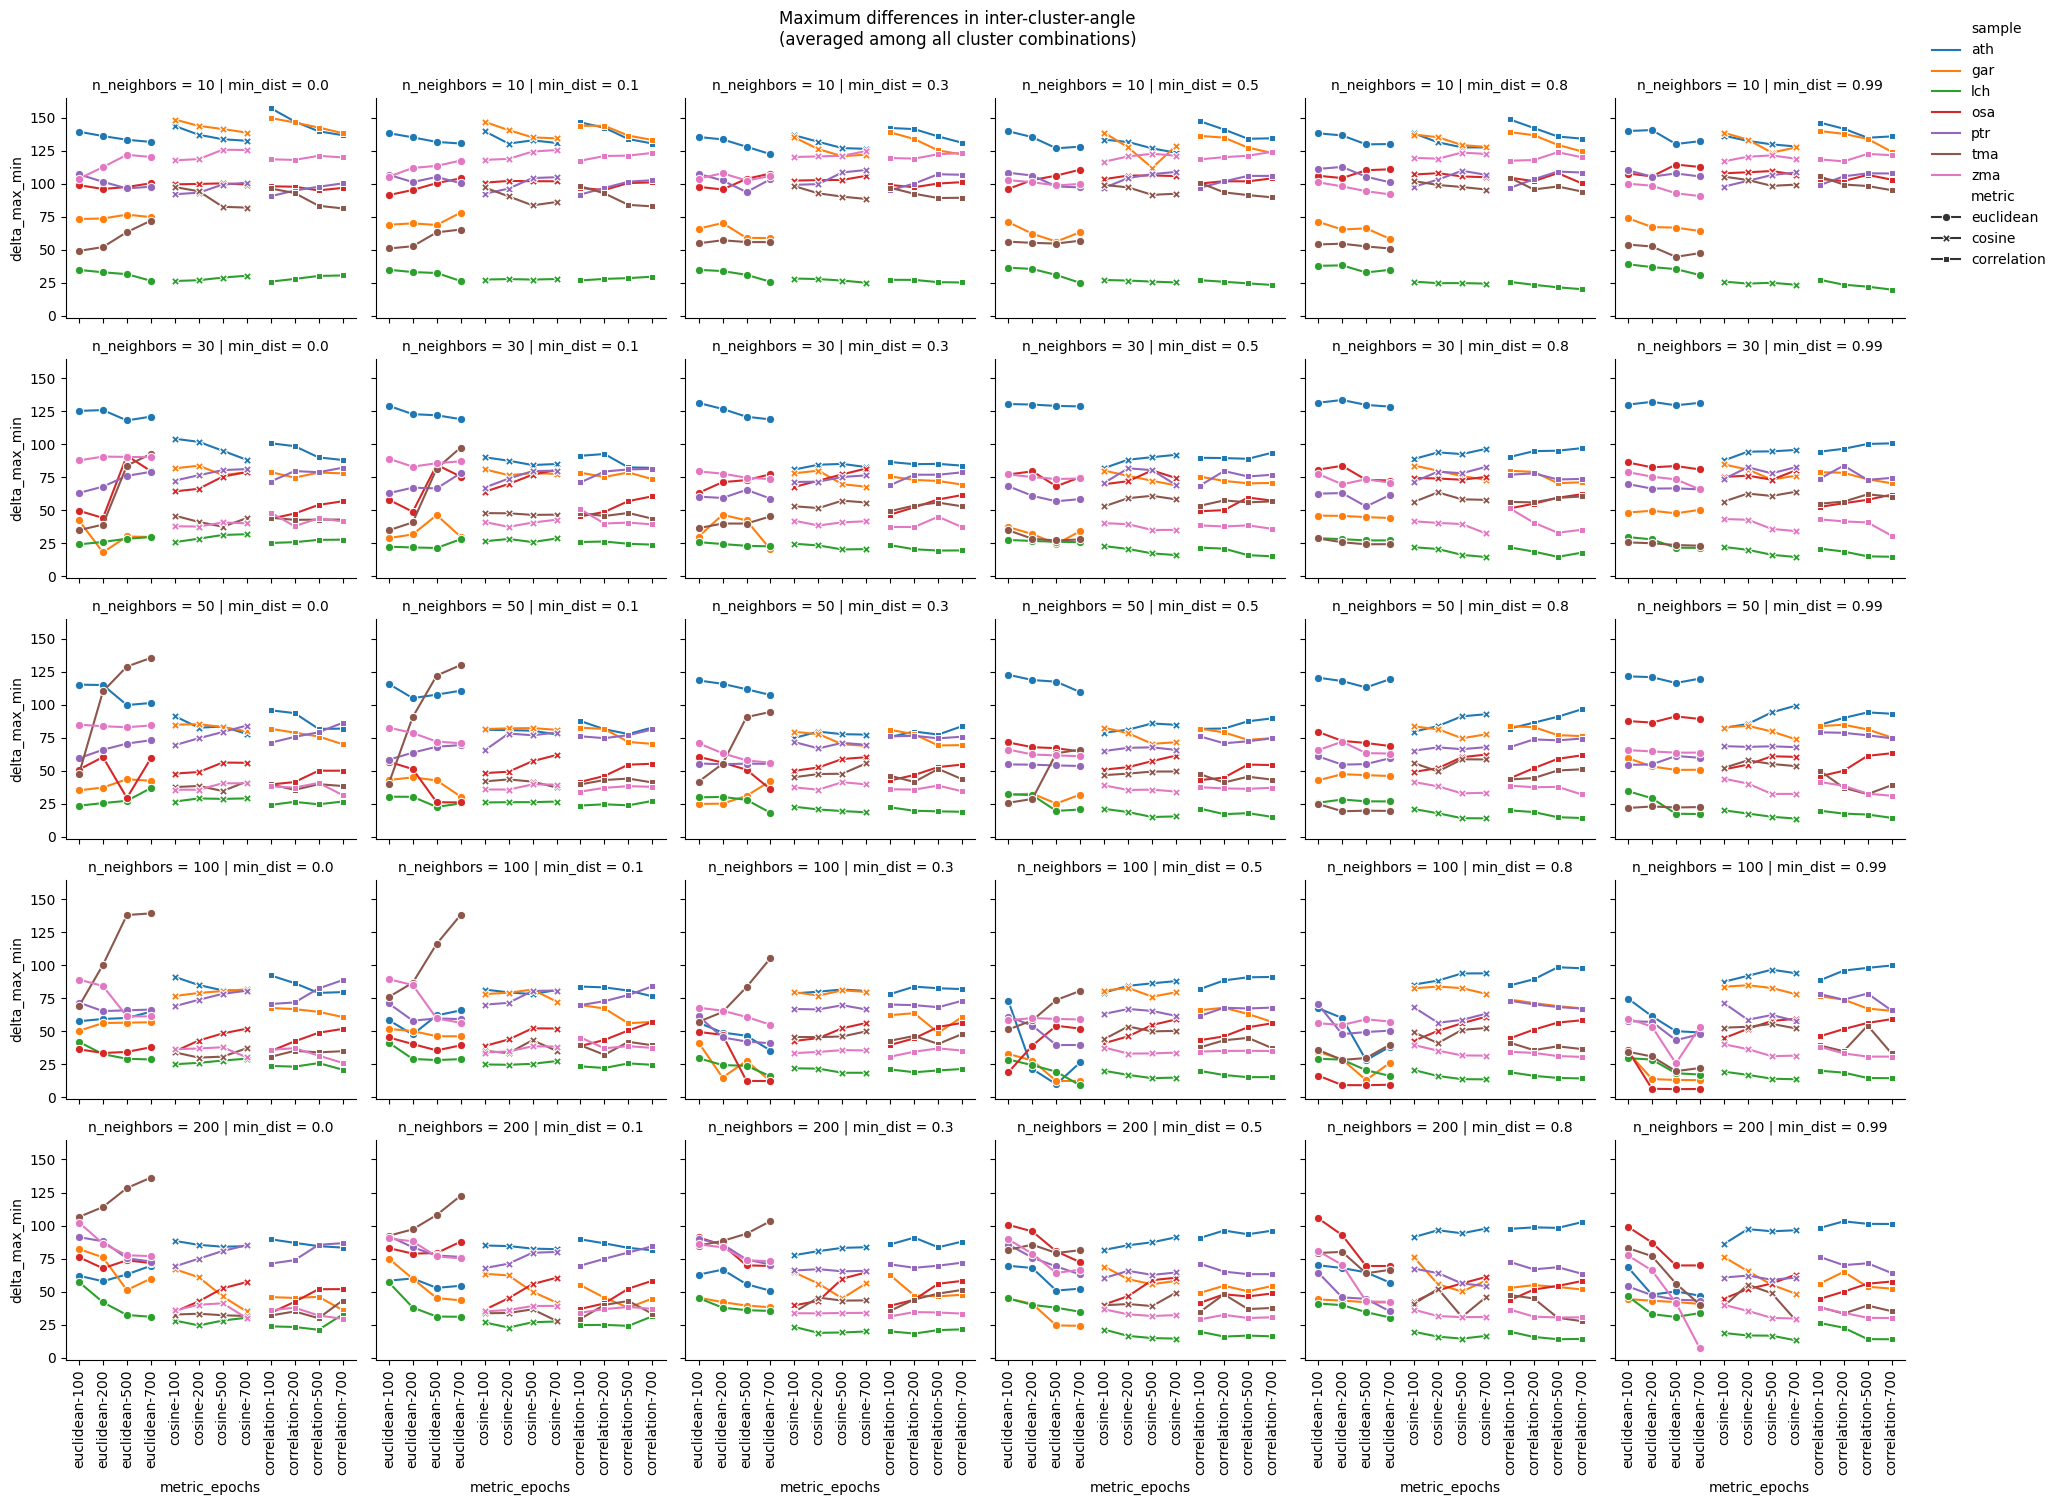

In [20]:
# data = stat_df.groupby(["n_neighbors", "min_dist", "metric", "n_epochs", "sample"]).mean().reset_index()
data = stat_df.copy()
data["metric_epochs"] = data.apply(lambda x: f"{x.metric}-{x.n_epochs}", axis=1)
g = sns.FacetGrid(
    data,
    row="n_neighbors",
    col="min_dist",
)
g.map_dataframe(
    sns.lineplot,
    x="metric_epochs",
    y="delta_max_min",
    hue="sample",
    style="metric",
    palette="tab10",
    err_style=None,
    dashes=False,
    markers=True
)
# g.map_dataframe(
#     sns.stripplot,
#     x="metric_epochs",
#     y="delta_max_min",
#     hue="sample",
#     palette="tab10",
#     dodge=.3
# )
g.tick_params(axis="x", rotation=90)
g.add_legend()
g.fig.suptitle("Maximum differences in inter-cluster-angle\n(averaged among all cluster combinations)", y=1.0)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
g.savefig(paths.outdir() / "average_max_angular_difference.svg")

In [17]:
data = stat_df.copy()
g_df = data.groupby(["sample", "param_set"]).agg(
    avg_delta=("delta_max_min", "mean")
)
min_delta_params = g_df.groupby(["sample"]).idxmin()["avg_delta"].tolist()

In [23]:
# data = stat_df.groupby(["n_neighbors", "min_dist", "metric", "n_epochs", "sample"]).mean().reset_index()
data = stat_df.copy()
data["metric_epochs"] = data.apply(lambda x: f"{x.metric}-{x.n_epochs}", axis=1)
tmp_outdir = paths.outdir() / "boxplot_max_diff"
os.makedirs(tmp_outdir, exist_ok=True)
for sample in samples:
    g = sns.FacetGrid(
        data.query("sample == @sample"),
        row="n_neighbors",
        col="min_dist",
    )
    # g.map_dataframe(
    #     sns.violinplot,
    #     x="delta_max_min",
    #     y="metric_epochs",
    #     hue="metric",
    #     palette="tab10",
    #     split=True,
    #     fill=False,
    #     inner="quart",
    #     cut=0,
    # )
    g.map_dataframe(
        sns.boxplot,
        x="metric_epochs",
        y="delta_max_min",
        hue="metric",
        palette="tab10",
        width=.5,
        fill=False
    )
    g.tick_params(axis="x", rotation=90)
    g.add_legend()
    g.fig.suptitle(f"Maximum differences in inter-cluster-angle | {sample}\n(each box represents 168 cluster combinations", y=1.0)
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    g.savefig(tmp_outdir / f"boxplot_max_angular_difference_{sample}.svg")
    plt.close("all")

### Show extreme UMAP embeddings

Plot UMAPs where max(degree), min(degree) are observed

In [27]:
def plot_umap(path_embeddings, cluster_df, ax, highlights=None, bold=[], palette=None, **kwargs):
    # combinding embeddings with cluster_df
    embeddings = pd.read_csv(path_embeddings, index_col=0)
    embeddings_clusters = pd.merge(embeddings, cluster_df, left_index=True, right_index=True)

    # calculate cluster centroids
    cluster_centroids = embeddings_clusters.groupby(["cluster"]).median()
    cluster_centroids["cluster"] = cluster_centroids.index.tolist()

    # highlight all cluster if `hightlights` is not specified
    if highlights is None:
        highlights = embeddings_clusters["cluster"].unique().tolist()

    # assign non-highlight cluster as lightgray
    if palette is not None:
        palette = palette.copy()
        for clust in palette.keys():
            if clust not in highlights:
                palette[clust] = "lightgray"
        
    # plot cells
    sns.scatterplot(
        embeddings_clusters,
        x="UMAP1",
        y="UMAP2",
        hue="cluster",
        palette=palette,
        ax=ax,
        **kwargs
    )

    # plot cluster centorid and text lable
    for index, row in cluster_centroids.loc[highlights, :].iterrows():
        ax.text(
            x=row["UMAP1"],
            y=row["UMAP2"],
            s=row["cluster"],
            color="black",
            fontsize="large",
            fontweight="black" if row["cluster"] in bold else "normal",
            ha="center",
            va="center"
        )    
    # if highlights is not None:
    #     return palette, cluster_centroids
    #     fig = sns.scatterplot(
    #         cluster_centroids,
    #         x="UMAP1",
    #         y="UMAP2",
    #         c=[palette[c] for c in cluster_centroids["cluster"]],
    #         ax=ax,
    #         s=kwargs.get(s, 4) * 40
    #     )
    ax.relim()
    ax.autoscale_view()
    ax.set_axis_off()
    
    return

In [ ]:
max_min_umap_dir = paths.outdir() / "max_min_angle_umap"
os.makedirs(max_min_umap_dir, exist_ok=True)
for metric in param_sets["metric"].unique().tolist():
    for sample in samples:
        ica_max_min = stat_df.query("(sample == @sample) & (metric == @metric)")
    
        #
        g_max = sns.FacetGrid(ica_max_min, row="n_neighbors", col="min_dist", sharex=False, sharey=False)
        g_min = sns.FacetGrid(ica_max_min, row="n_neighbors", col="min_dist", sharex=False, sharey=False)
        
        #
        row_levels = {value: idx for idx, value in enumerate(ica_max_min["n_neighbors"].unique())}
        col_levels = {value: idx for idx, value in enumerate(ica_max_min["min_dist"].unique())}
        
        #
        labels = cluster_dfs[sample]["cluster"].unique()
        colors = plt.get_cmap("tab10").colors
        palette = {k: colors[i % len(colors)] for i, k in enumerate(labels)}
        
        #
        for nn in ica_max_min["n_neighbors"].unique():
            for md in ica_max_min["min_dist"].unique():
                # 
                row_n = row_levels[nn]
                col_n = col_levels[md]
        
                # 
                ica_diff_subset = ica_max_min.query("(n_neighbors == @nn) & (min_dist == @md) & (n_epochs == 200)").reset_index()
                ica_max_diff = ica_diff_subset.loc[ica_diff_subset["delta_max_min"].idxmax(), :]
                
                #
                path_embeddings_max = paths.embeddings(
                    sample=sample,
                    seed=ica_max_diff["max_degree_seed"],
                    param_set=ica_max_diff["param_set"]
                )
                plot_umap(
                    path_embeddings_max,
                    cluster_dfs[sample], 
                    ax=g_max.axes[row_n][col_n], 
                    highlights=ica_max_diff[["vertex", "cluster_a", "cluster_b"]].values.astype(str).tolist(),
                    bold=ica_max_diff[["vertex"]].values.astype(str).tolist(),
                    palette=palette.copy(),
                    legend=False, 
                    s=1,
                    edgecolors="none"
                )
    
                # 
                path_embeddings_min = paths.embeddings(
                    sample=sample,
                    seed=ica_max_diff["min_degree_seed"],
                    param_set=ica_max_diff["param_set"]
                )
                plot_umap(
                    path_embeddings_min, 
                    cluster_dfs[sample],
                    ax=g_min.axes[row_n][col_n], 
                    highlights=ica_max_diff[["vertex", "cluster_a", "cluster_b"]].values.astype(str).tolist(),
                    bold=ica_max_diff[["vertex"]].values.astype(str).tolist(),
                    palette=palette,
                    legend=False, 
                    s=1,
                    edgecolors="none"
                )

        # save and close
        g_max.savefig(max_min_umap_dir / f"max_angle_umap_metric={metric}_n_epochs=200_sample={sample}.png")
        g_min.savefig(max_min_umap_dir / f"min_angle_umap_metric={metric}_n_epochs=200_sample={sample}.png")
        plt.close("all")

## See if SD and Max-delta inter-cluster-angle are lower after Procrustes alignments

In [30]:
align_per_n = [10, 20, 50, 100]
temp_list = []
for sample, n, param_set in list(product(samples, align_per_n, param_sets.index.tolist())):
    foo = pd.read_csv(paths.ica_aligned(sample=sample, n=n, param_set=param_set))
    foo = foo.query("(vertex < 8) & (cluster_a < 8) & (cluster_b < 8)")
    foo["sample"] = sample
    foo["param_set"] = param_set
    foo["align_per_n"] = n
    def cos_to_degree(x):
        return np.degrees(np.arccos(x))
    foo["degree"] = foo["cos_similarity"].apply(cos_to_degree)
    foo = foo.drop(columns=["cos_similarity"])
    foo = foo.merge(param_sets, left_on="param_set", right_index=True)
    temp_list.append(foo)
    
ica_df_aligned = pd.concat(temp_list, ignore_index=True)
del temp_list

Calculate SD of inter-cluster-angle across all cluster combinations

In [31]:
stat_df_aligned = pd.DataFrame()
stat_df_aligned = ica_df_aligned.groupby(
    ["sample", "align_per_n", "param_set", "vertex", "cluster_a", "cluster_b"]
).agg(
    max_degree=("degree", "max"),
    min_degree=("degree", "min"),
    degree_sd=("degree", "std")
)
stat_df_aligned["delta_max_min"] = stat_df_aligned.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
stat_df_aligned = pd.merge(stat_df_aligned, param_sets, left_on="param_set", right_index=True, how="left")
stat_df_aligned = stat_df_aligned.reset_index()

Plot average SD among cluster combinations  
For each sample:  
- row = n_neighbors
- col = min_dist
- hue = align_per_n
- x = metric_epochs
- y = SD


In [26]:
stat_df_aligned.head()

,sample,align_per_n,param_set,vertex,cluster_a,cluster_b,max_degree,min_degree,degree_sd,delta_max_min,n_neighbors,min_dist,metric,n_epochs
0,ath,10,0,0,1,2,31.879260,0.450568,6.350358,31.428693,10,0.0,euclidean,100
1,ath,10,0,0,1,3,19.705871,6.557135,2.469506,13.148736,10,0.0,euclidean,100
2,ath,10,0,0,1,4,19.959476,4.092576,2.712330,15.866899,10,0.0,euclidean,100
3,ath,10,0,0,1,5,16.614956,0.032004,4.119145,16.582952,10,0.0,euclidean,100
4,ath,10,0,0,1,6,37.191420,16.454337,3.488805,20.737083,10,0.0,euclidean,100


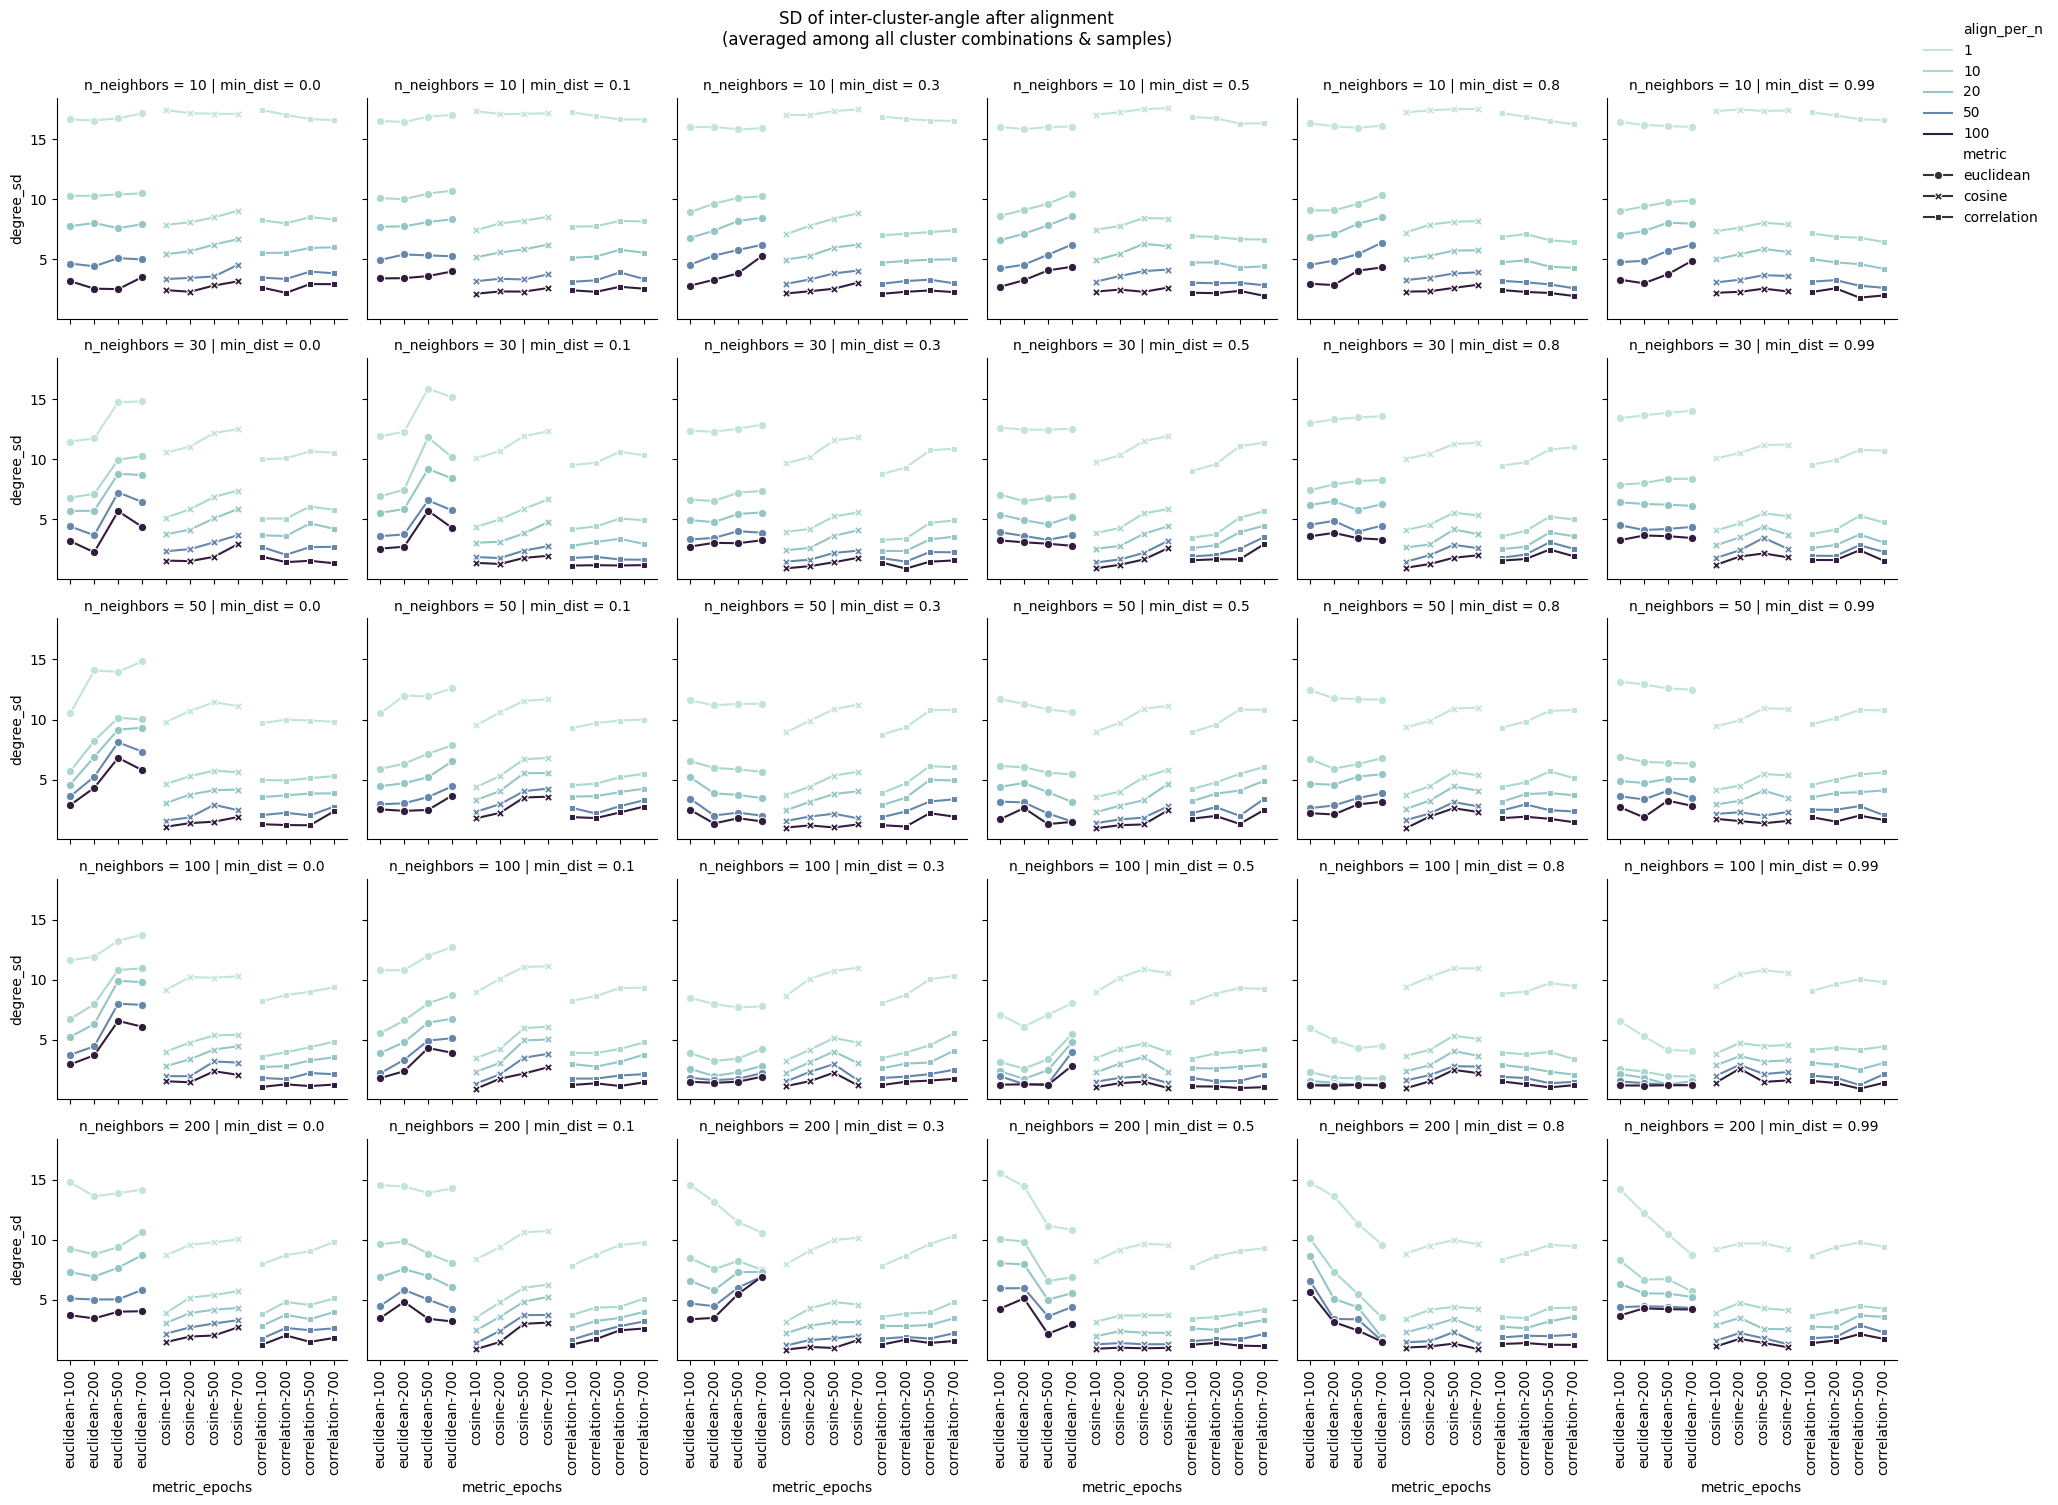

In [85]:
data = stat_df.copy()
data["align_per_n"] = 1
data = pd.concat([stat_df_aligned, data[stat_df_aligned.columns]])
data["metric_epochs"] = data.apply(lambda x: f"{x.metric}-{x.n_epochs}", axis=1)
g = sns.FacetGrid(
    data,
    row="n_neighbors",
    col="min_dist",
)
g.map_dataframe(
    sns.lineplot,
    x="metric_epochs",
    y="degree_sd",
    hue="align_per_n",
    style="metric",
    palette="ch:start=.5,rot=-.5",
    err_style=None,
    dashes=False,
    markers=True
)
g.tick_params(axis="x", rotation=90)
g.add_legend()
g.fig.suptitle("SD of inter-cluster-angle after alignment\n(averaged among all cluster combinations & samples)", y=1.0)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
g.savefig(paths.outdir() / "average_angle_sd_aligned.svg")

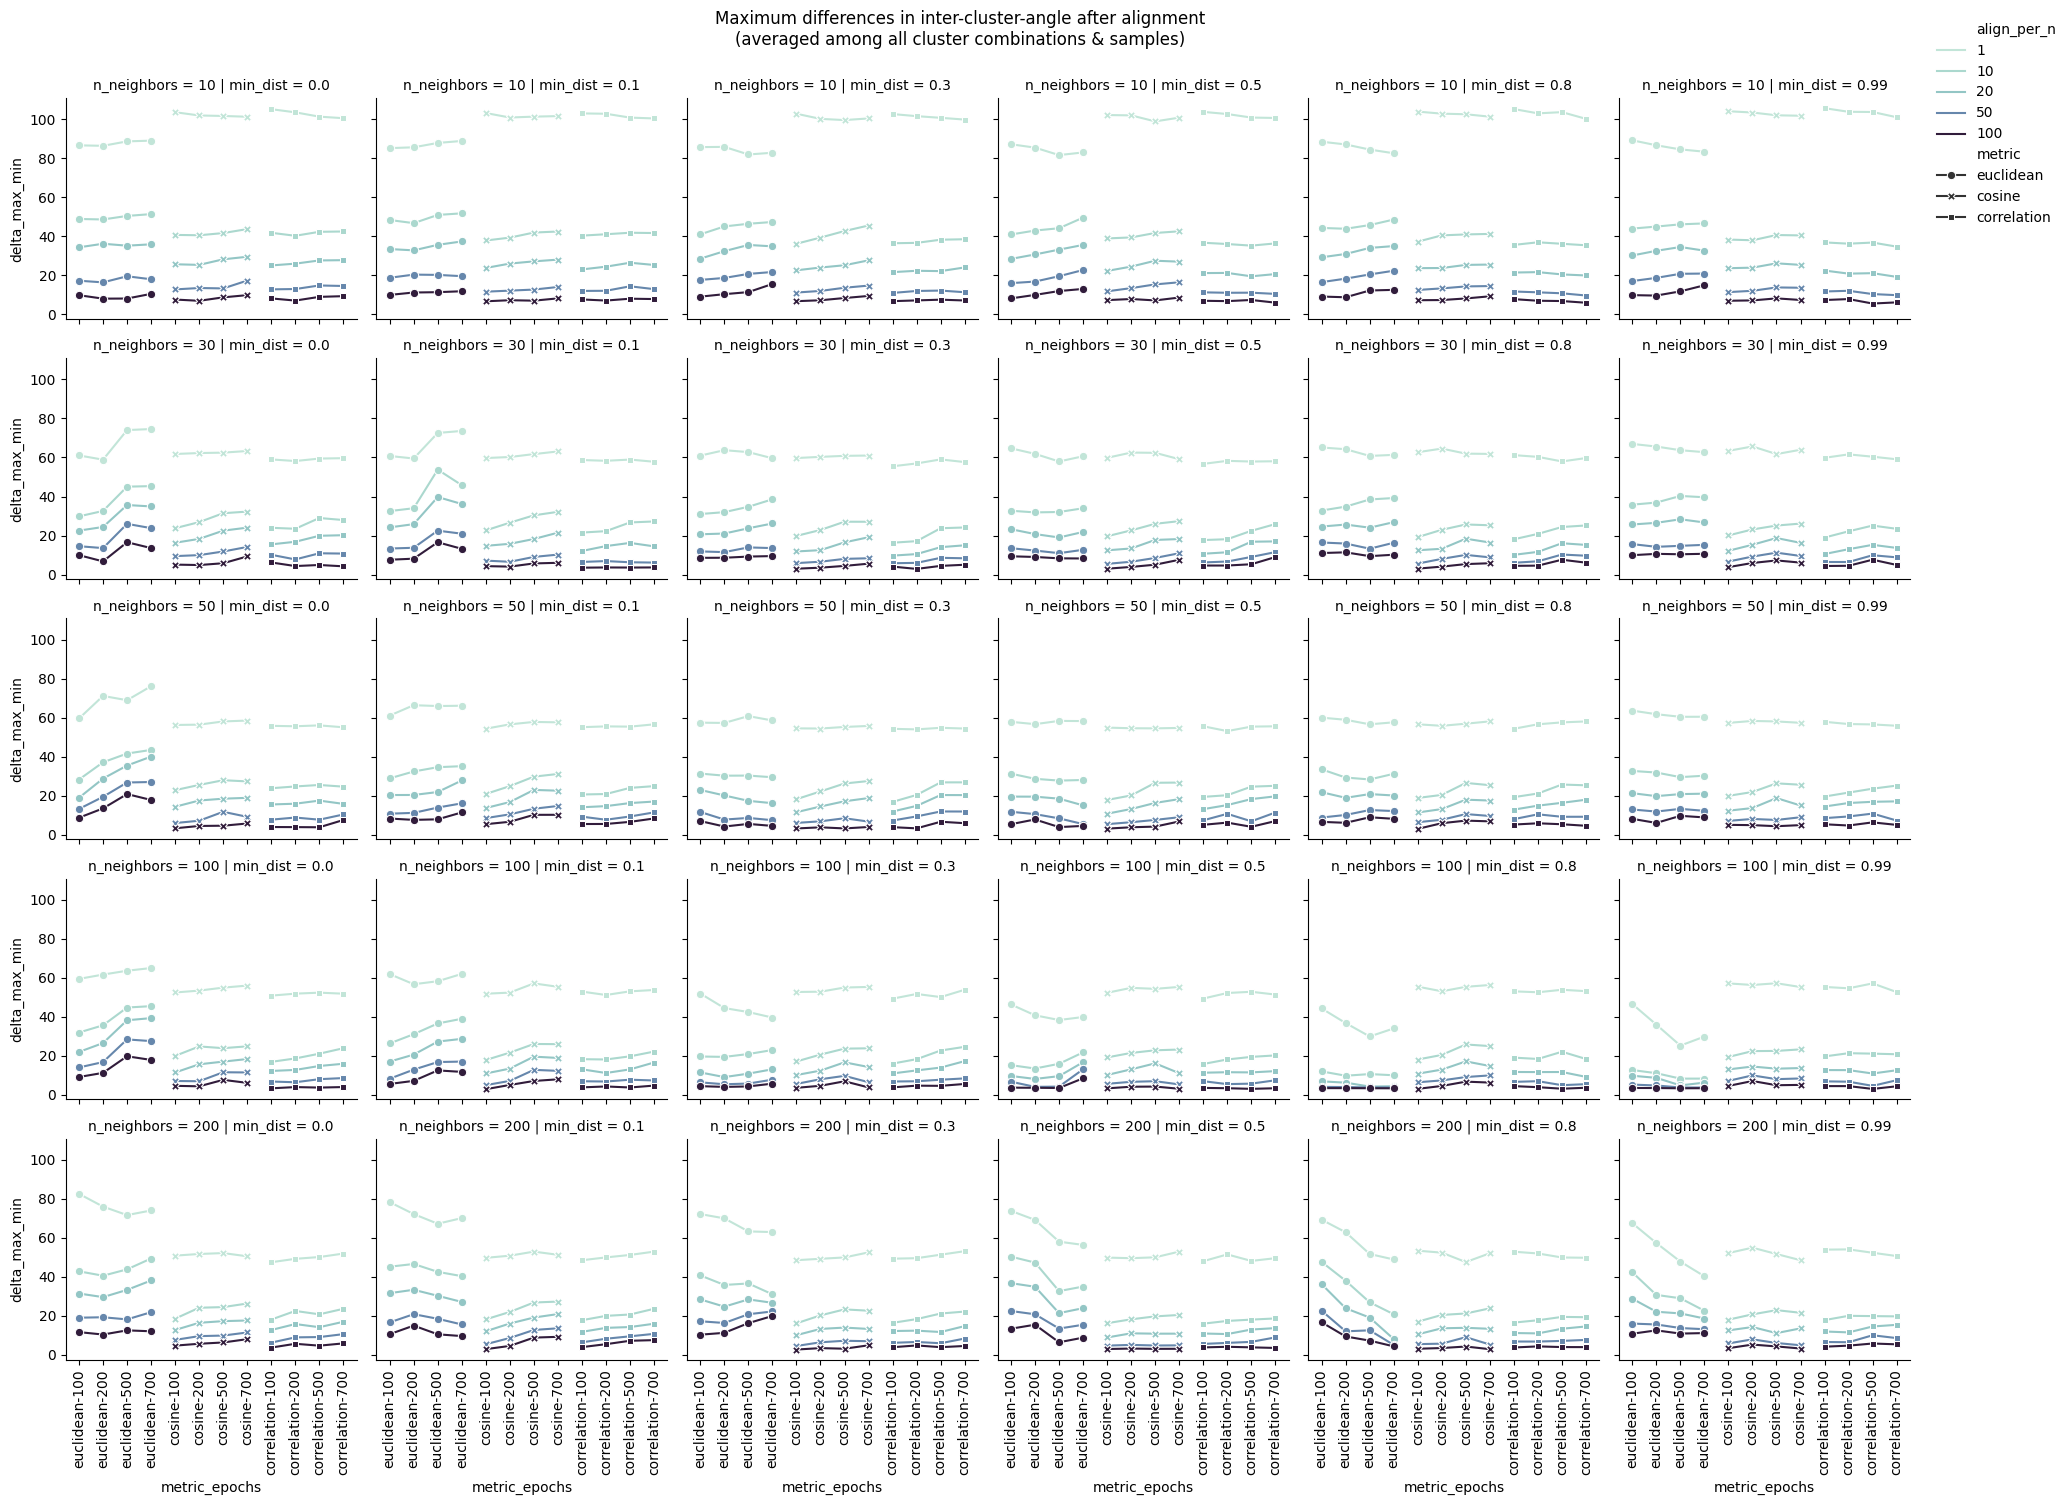

In [88]:
data = stat_df.copy()
data["align_per_n"] = 1
data = pd.concat([stat_df_aligned, data[stat_df_aligned.columns]])
data["metric_epochs"] = data.apply(lambda x: f"{x.metric}-{x.n_epochs}", axis=1)
g = sns.FacetGrid(
    data,
    row="n_neighbors",
    col="min_dist",
)
g.map_dataframe(
    sns.lineplot,
    x="metric_epochs",
    y="delta_max_min",
    hue="align_per_n",
    style="metric",
    palette="ch:start=.5,rot=-.5",
    err_style=None,
    dashes=False,
    markers=True
)
g.tick_params(axis="x", rotation=90)
g.add_legend()
g.fig.suptitle("Maximum differences in inter-cluster-angle after alignment\n(averaged among all cluster combinations & samples)", y=1.0)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
g.savefig(paths.outdir() / "average_max_angular_difference_aligned.svg")

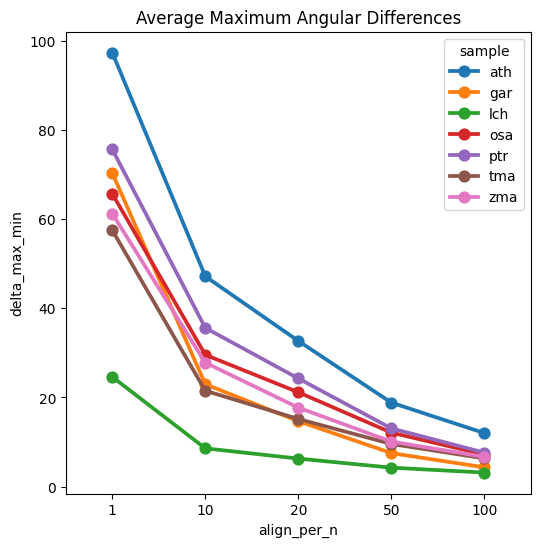

In [32]:
data = stat_df.copy()
data["align_per_n"] = 1
data = pd.concat([stat_df_aligned, data[stat_df_aligned.columns]])
data["metric_epochs"] = data.apply(lambda x: f"{x.metric}-{x.n_epochs}", axis=1)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sns.pointplot(
    data,
    x="align_per_n",
    y="delta_max_min",
    hue="sample",
    palette="tab10",
    errorbar=None,
    ax=ax
)
ax.set_title("Average Maximum Angular Differences")
fig.savefig("avg_max_angular_diff_by_sample.svg")

### See whether extremely high-epochs stabilize UMAP embeddings

In [96]:
ica_df_highe = pd.DataFrame()
df_list = []
for sample in ["ptr", "gar"]:
    with concurrent.futures.ProcessPoolExecutor(max_workers=48) as executor:
        print(f"sample={sample}", end="")
        # submit jobs to pool
        futures = [
            executor.submit(pd.read_csv, paths.ica_high_epochs(sample=sample, seed=seed)) 
            for seed in seeds
        ]

        # store concurrent results to list
        for fut in tqdm(
            concurrent.futures.as_completed(futures),
            total=len(futures)
        ):
            df_temp = fut.result()
            df_temp["sample"] = sample
            mask1 = df_temp["vertex"] < 8
            mask2 = df_temp["cluster_a"] < 8
            mask3 = df_temp["cluster_b"] < 8
            df_temp = df_temp[mask1 & mask2 & mask3]
            df_list.append(df_temp)

# concat dataframes
print("Concat...")
ica_df_highe = pd.concat(df_list, ignore_index=True)
ica_df_highe["degree"] = ica_df_highe["cos_similarity"].apply(
    lambda x: np.degrees(np.arccos(x))
)
ica_df_highe.drop(columns=["cos_similarity"], inplace=True)
del df_list

sample=ptr

100%|█████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:12<00:00, 77.85it/s]


sample=gar

100%|█████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 75.32it/s]


Concat...


In [98]:
ica_df_highe.head()

,param_set,seed,vertex,cluster_a,cluster_b,sample,degree
0,82,68878,0,1,2,ptr,9.727504
1,82,68878,0,1,3,ptr,68.329495
2,82,68878,0,1,4,ptr,18.412241
3,82,68878,0,1,5,ptr,7.008732
4,82,68878,0,1,6,ptr,41.193992


In [99]:
stat_df_highe = pd.DataFrame()
stat_df_highe = ica_df_highe.groupby(
    ["sample", "param_set", "vertex", "cluster_a", "cluster_b"]
).agg(
    max_degree=("degree", "max"),
    min_degree=("degree", "min"),
    degree_sd=("degree", "std")
)
stat_df_highe["delta_max_min"] = stat_df_highe.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
stat_df_highe = pd.merge(stat_df_highe, param_sets_highe, left_on="param_set", right_index=True, how="left")
stat_df_highe = stat_df_highe.reset_index()
stat_df_highe.head()

,sample,param_set,vertex,cluster_a,cluster_b,max_degree,min_degree,degree_sd,delta_max_min,n_neighbors,min_dist,metric,n_epochs
0,gar,0,0,1,2,24.294252,4.827028,2.538714,19.467223,10,0.0,euclidean,10000
1,gar,0,0,1,3,17.507357,1.863611,2.990525,15.643746,10,0.0,euclidean,10000
2,gar,0,0,1,4,169.249535,84.716538,11.226732,84.532997,10,0.0,euclidean,10000
3,gar,0,0,1,5,18.898117,0.039137,2.422077,18.858980,10,0.0,euclidean,10000
4,gar,0,0,1,6,68.384138,0.077616,7.850349,68.306522,10,0.0,euclidean,10000


In [101]:
stat_df_all_epochs = pd.concat([
    stat_df.query("(sample == 'ptr') | (sample == 'gar')")[stat_df_highe.columns],
    stat_df_highe
])
stat_df_all_epochs.head()

,sample,param_set,vertex,cluster_a,cluster_b,max_degree,min_degree,degree_sd,delta_max_min,n_neighbors,min_dist,metric,n_epochs
60480,gar,0,0,1,2,29.545406,4.735784,3.984300,24.809622,10,0.0,euclidean,100
60481,gar,0,0,1,3,27.252889,15.316006,1.823596,11.936884,10,0.0,euclidean,100
60482,gar,0,0,1,4,178.370253,108.788771,9.213091,69.581482,10,0.0,euclidean,100
60483,gar,0,0,1,5,27.160192,5.635012,1.878533,21.525180,10,0.0,euclidean,100
60484,gar,0,0,1,6,61.323537,25.665703,5.377021,35.657834,10,0.0,euclidean,100


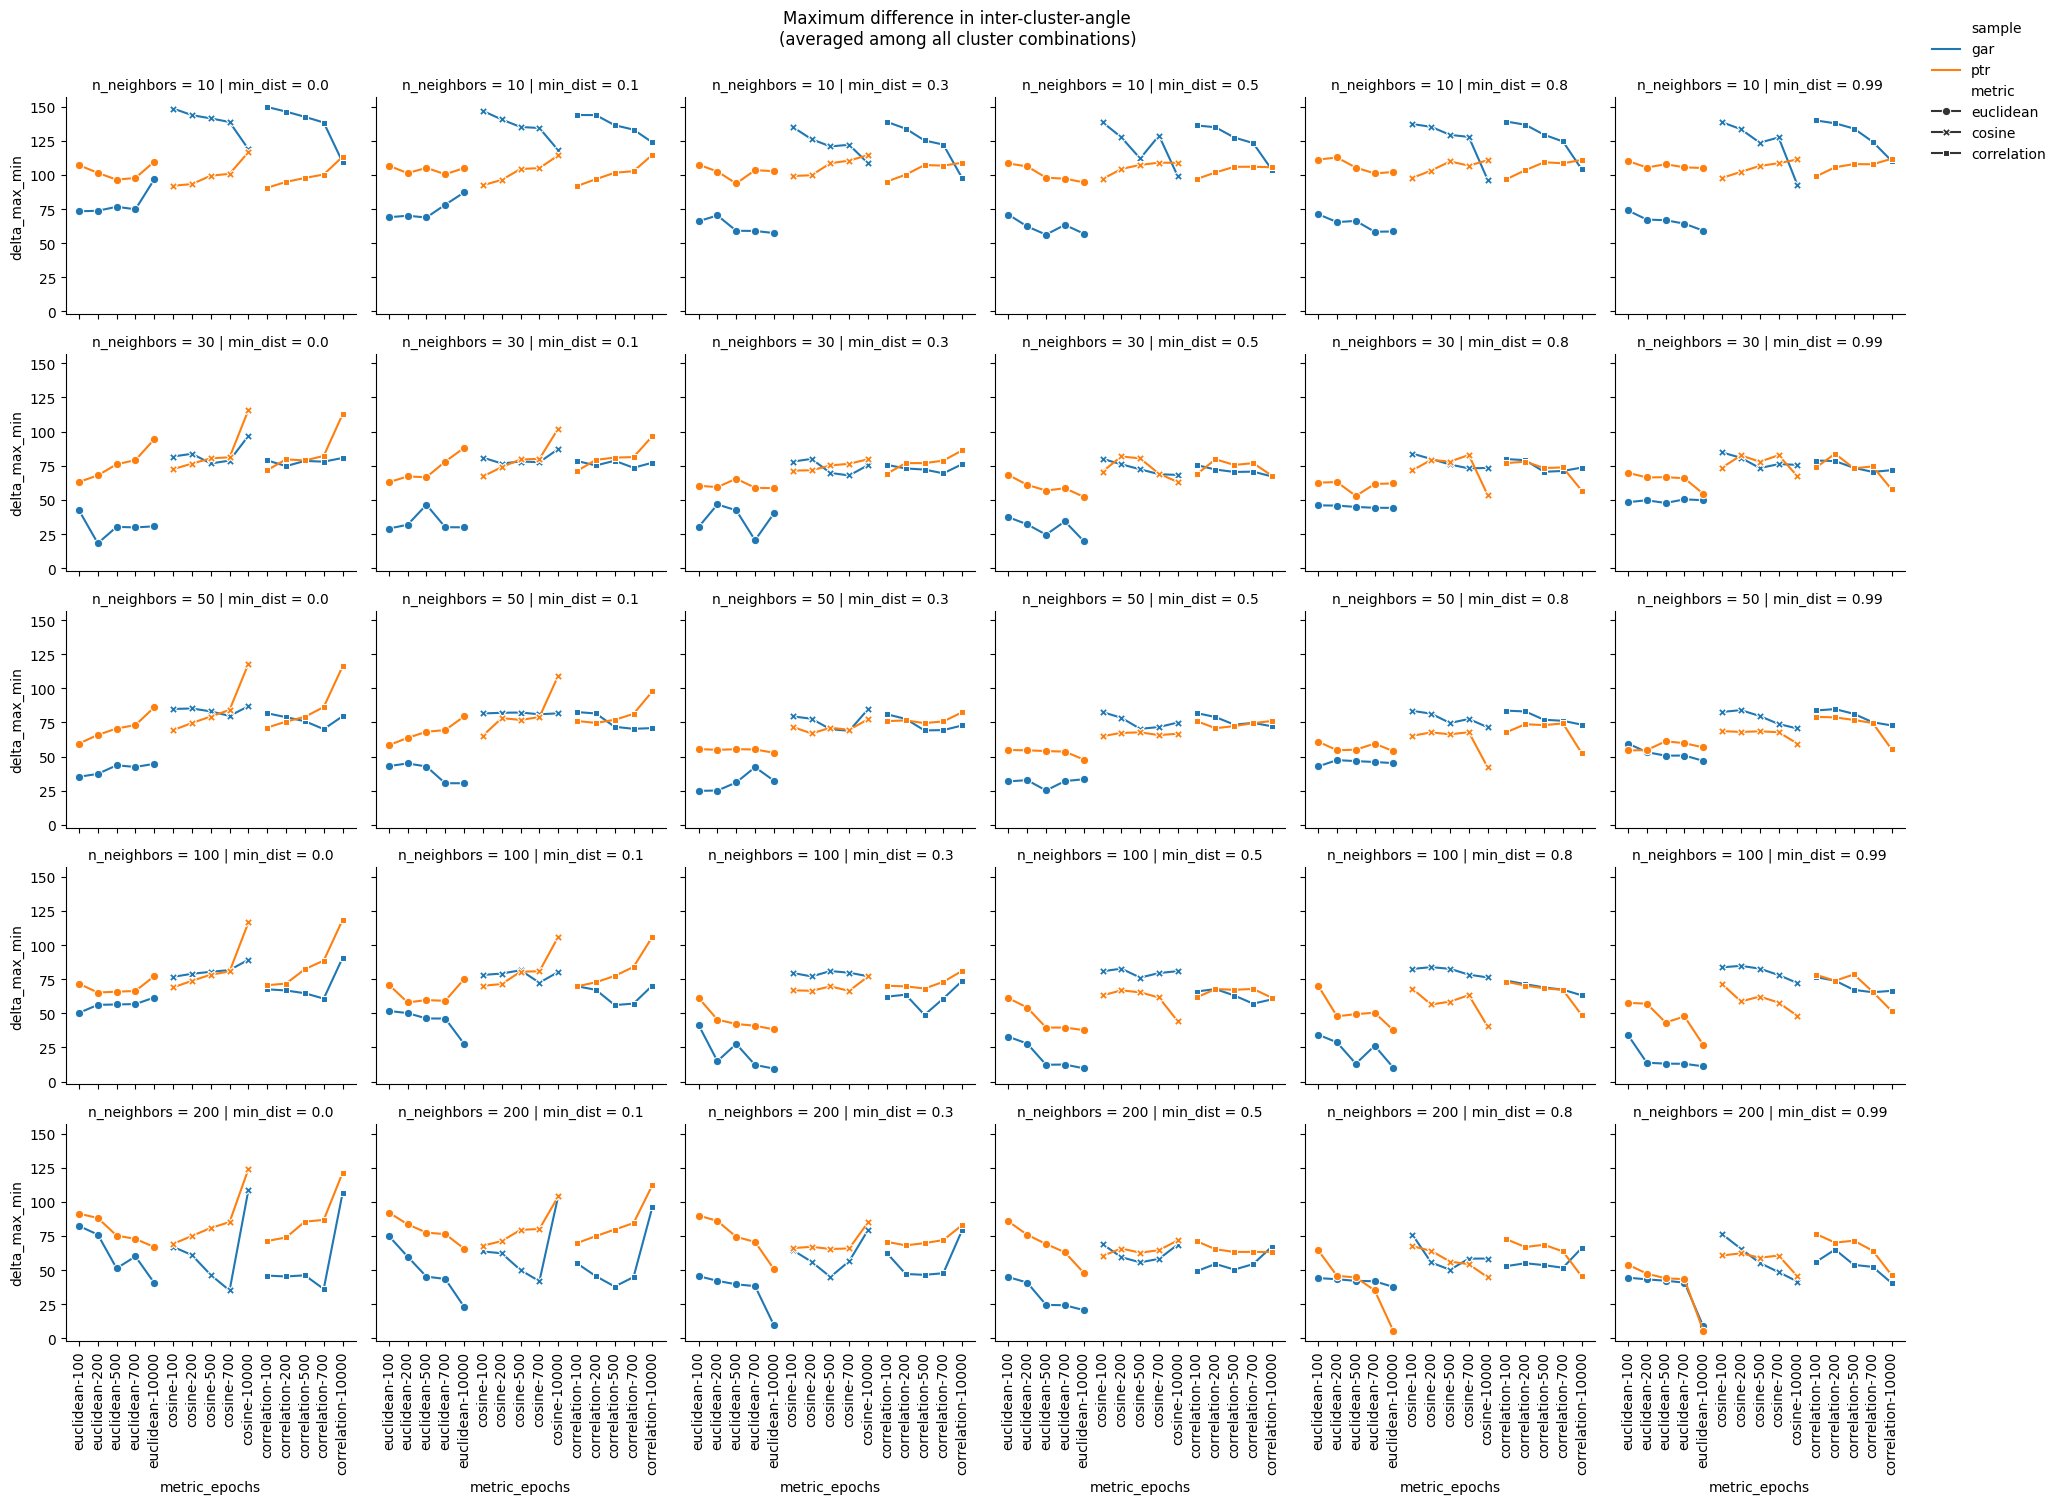

In [105]:
# data = stat_df.groupby(["n_neighbors", "min_dist", "metric", "n_epochs", "sample"]).mean().reset_index()
data = stat_df_all_epochs.copy()
data = data.sort_values(by=["metric", "n_epochs"], ascending=[False, True])
data["metric_epochs"] = data.apply(lambda x: f"{x.metric}-{x.n_epochs}", axis=1)
# data["n_epochs"] = data["n_epochs"].astype(str)
g = sns.FacetGrid(
    data,
    row="n_neighbors",
    col="min_dist",
)
g.map_dataframe(
    sns.lineplot,
    x="metric_epochs",
    y="delta_max_min",
    hue="sample",
    style="metric",
    palette="tab10",
    err_style=None,
    dashes=False,
    markers=True
)
g.tick_params(axis="x", rotation=90)
g.add_legend()
g.fig.suptitle("Maximum difference in inter-cluster-angle\n(averaged among all cluster combinations)", y=1.0)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
g.savefig(paths.outdir() / "average_max_angular_difference_high_epochs.svg")

In [289]:
data = stat_df_all_epochs.copy()
data = data.sort_values(by=["metric", "n_epochs"], ascending=[False, True])
data["metric_epochs"] = data.apply(lambda x: f"{x.metric}-{x.n_epochs}", axis=1)
for sample in samples:
    if not sample in data["sample"].unique():
        continue
    g = sns.FacetGrid(
        data.query("sample == @sample"),
        row="n_neighbors",
        col="min_dist",
    )
    g.map_dataframe(
        sns.boxplot,
        x="metric_epochs",
        y="delta_max_min",
        hue="metric",
        palette="tab10",
        width=.5,
        fill=False
    )
    g.tick_params(axis="x", rotation=90)
    g.add_legend()
    g.fig.suptitle(f"Maximum differences in inter-cluster-angle | {sample}\n(each box represents 168 cluster combinations", y=1.0)
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    g.savefig(tmp_outdir / f"boxplot_max_angular_difference_high_epochs_{sample}.svg")
    plt.close("all")

### Plot stable embeddings

In [33]:
outdir_stable_umap = paths.outdir() / "stable_umap"
os.makedirs(outdir_stable_umap, exist_ok=True)
for sample, param_set_best in min_delta_params:
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    embedding_func = paths.embeddings
    plot_umap(
        embedding_func(
            sample=sample,
            seed=seeds[0],
            param_set=param_set_best
        ),
        cluster_dfs[sample], 
        ax=ax, 
        legend=False, 
        s=4 if sample in ["ath", "osa"] else 8,
        edgecolors="none"
    )
    n_neighbors_best = int(param_sets.loc[param_set_best, "n_neighbors"])
    min_dist_best = float(param_sets.loc[param_set_best, "min_dist"])
    metric_best = param_sets.loc[param_set_best, "metric"]
    n_epochs_best = int(param_sets.loc[param_set_best, "n_epochs"])
    ax.set_title(f"{sample}_{metric_best}_{n_neighbors_best}_{min_dist_best}_{n_epochs_best}")
    fig.savefig(outdir_stable_umap / f"{sample}_{metric_best}_{n_neighbors_best}_{min_dist_best}_{n_epochs_best}.svg")
    plt.close()

### Compare aligned embeddings to "stable" embeddings

In [20]:
from scipy.linalg import orthogonal_procrustes

class EmbeddingAlignment:
    @staticmethod
    def procrustes_alignment(Y: np.ndarray, X: np.ndarray):
        Xc = X - X.mean(axis=0)
        Yc = Y - Y.mean(axis=0)
        R, _ = orthogonal_procrustes(Yc, Xc)
        Y_aligned = Yc @ R
        rmsd = np.sqrt(((Xc - Y_aligned) ** 2).sum(axis=1).mean())
        return Y_aligned, rmsd

In [21]:
# the param_set that give the most stable embedding results
min_delta_params

[('ath', 254),
 ('gar', 243),
 ('lch', 255),
 ('osa', 278),
 ('ptr', 339),
 ('tma', 193),
 ('zma', 351)]

In [96]:
rmsd_df_list = []
for sample, param_set_best in min_delta_params:
    print(f"Processing sample, param_set: {sample}, {param_set_best}")
    
    # get params
    n_neighbors_best = int(param_sets.loc[param_set_best, "n_neighbors"])
    min_dist_best = float(param_sets.loc[param_set_best, "min_dist"])
    metric_best = param_sets.loc[param_set_best, "metric"]
    n_epochs_best = int(param_sets.loc[param_set_best, "n_epochs"])

    # read one stable embedding (use the first seed)
    embeddings_path_func = paths.embeddings if n_epochs_best < 10000 else paths.embeddings_hepochs
    stable_embedding = pd.read_csv(
        embeddings_path_func(
            sample=sample,
            param_set=param_set_best,
            seed=seeds[0]
        ),
        index_col = 0
    )

    # 
    N = [10, 20, 50, 100]
    N_EPOCHS = [100, 200, 500, 700]
    
    # read aligned embeddings >> calculate median coordinate >> align to the stable embedding >> record RMSD
    def func1(sample, n_neighbors, min_dist, metric, n_epochs, n, batch):
        param_set_tmp = get_param_set(
            param_sets,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric=metric,
            n_epochs=n_epochs
        )[0]
        p = paths.aligned_embeddings(
            sample=sample, 
            n=n, 
            param_set=param_set_tmp, 
            batch=batch
        )
        foo = pd.read_csv(p, index_col = 0)
        foo["barcode"] = foo.index.to_list()
        foo = foo[["barcode", "UMAP1", "UMAP2"]].groupby("barcode", sort=False).median()
        aligned, rmsd = EmbeddingAlignment.procrustes_alignment(
            foo[["UMAP1", "UMAP2"]].values, 
            stable_embedding[["UMAP1", "UMAP2"]].values
        )
        return rmsd

    def func2(sample, n_neighbors, min_dist, metric, n_epochs, seed):
        param_set_tmp = get_param_set(
            param_sets,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric=metric,
            n_epochs=n_epochs
        )[0]
        p = paths.embeddings(sample=sample, seed=seed, param_set=param_set_tmp)
        foo = pd.read_csv(p, index_col=0)
        aligned, rmsd = EmbeddingAlignment.procrustes_alignment(
            foo[["UMAP1", "UMAP2"]].values, 
            stable_embedding[["UMAP1", "UMAP2"]].values
        )
        return rmsd
    
    for n_epochs in N_EPOCHS:
        print(f"n_epochs={n_epochs} | ", end="")
        # median vs. stable
        for n in N:
            print(f"n={n}, ", end="")
            rmsd_median = [
                func1(
                    sample=sample,
                    n_neighbors=n_neighbors_best,
                    min_dist=min_dist_best,
                    metric=metric_best,
                    n_epochs=n_epochs,
                    n=n,
                    batch=batch
                ) for batch in range(1000 // n)
            ]
            rmsd_df_list.append(
                pd.DataFrame({
                    "sample": [sample] * len(rmsd_median),
                    "rmsd": rmsd_median,
                    "n_epochs": [n_epochs] * len(rmsd_median),
                    "aligned_n": [n] * len(rmsd_median)
                })
            )

        # raw vs. stable
        print("raws")
        rmsd_raw = [
            func2(
                sample=sample,
                n_neighbors=n_neighbors_best,
                min_dist=min_dist_best,
                metric=metric_best,
                n_epochs=n_epochs,
                seed=seed
            ) for seed in seeds
        ]
        rmsd_df_list.append(
            pd.DataFrame({
                "sample": [sample] * len(rmsd_raw),
                "rmsd": rmsd_raw,
                "n_epochs": [n_epochs] * len(rmsd_raw),
                "aligned_n": [1] * len(rmsd_raw)
            })
        )

Processing sample, param_set: ath, 254
n_epochs=100 | n=10, n=20, n=50, n=100, raws
n_epochs=200 | n=10, n=20, n=50, n=100, raws
n_epochs=500 | n=10, n=20, n=50, n=100, raws
n_epochs=700 | n=10, n=20, n=50, n=100, raws
Processing sample, param_set: gar, 243
n_epochs=100 | n=10, n=20, n=50, n=100, raws
n_epochs=200 | n=10, n=20, n=50, n=100, raws
n_epochs=500 | n=10, n=20, n=50, n=100, raws
n_epochs=700 | n=10, n=20, n=50, n=100, raws
Processing sample, param_set: lch, 255
n_epochs=100 | n=10, n=20, n=50, n=100, raws
n_epochs=200 | n=10, n=20, n=50, n=100, raws
n_epochs=500 | n=10, n=20, n=50, n=100, raws
n_epochs=700 | n=10, n=20, n=50, n=100, raws
Processing sample, param_set: osa, 278
n_epochs=100 | n=10, n=20, n=50, n=100, raws
n_epochs=200 | n=10, n=20, n=50, n=100, raws
n_epochs=500 | n=10, n=20, n=50, n=100, raws
n_epochs=700 | n=10, n=20, n=50, n=100, raws
Processing sample, param_set: ptr, 339
n_epochs=100 | n=10, n=20, n=50, n=100, raws
n_epochs=200 | n=10, n=20, n=50, n=100, 

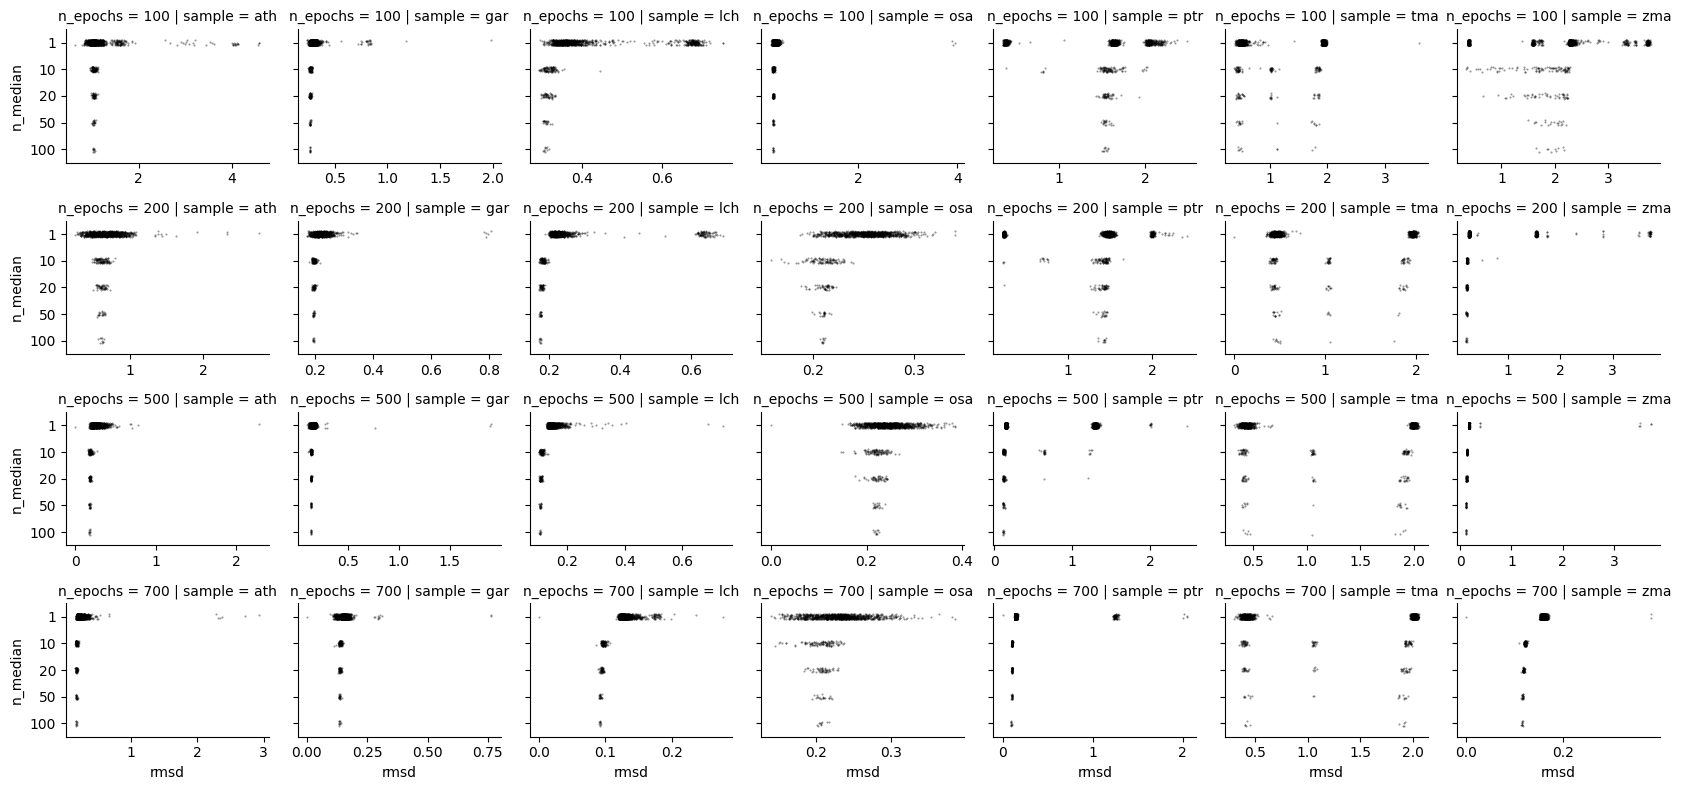

In [100]:
data = pd.concat(rmsd_df_list)
data = data.sort_values(by=["n_epochs", "aligned_n"])
data["n_epochs-n_median"] = data.apply(lambda x: f"{x.n_epochs} epochs x median-of-{x.aligned_n}", axis=1)
data["n_median"] = data["aligned_n"].astype(str)
g = sns.FacetGrid(
    data=data,
    col="sample",
    row="n_epochs",
    sharey=True,
    sharex=False,
    aspect=1.2,
    height=2
)
g.map_dataframe(
    sns.stripplot,
    x="rmsd",
    y="n_median",
    color="black",
    alpha=.4,
    s=1.5
)
sns.despine()
g.savefig(paths.outdir() / "rmsd_median_vs_stable_stripplot.svg")

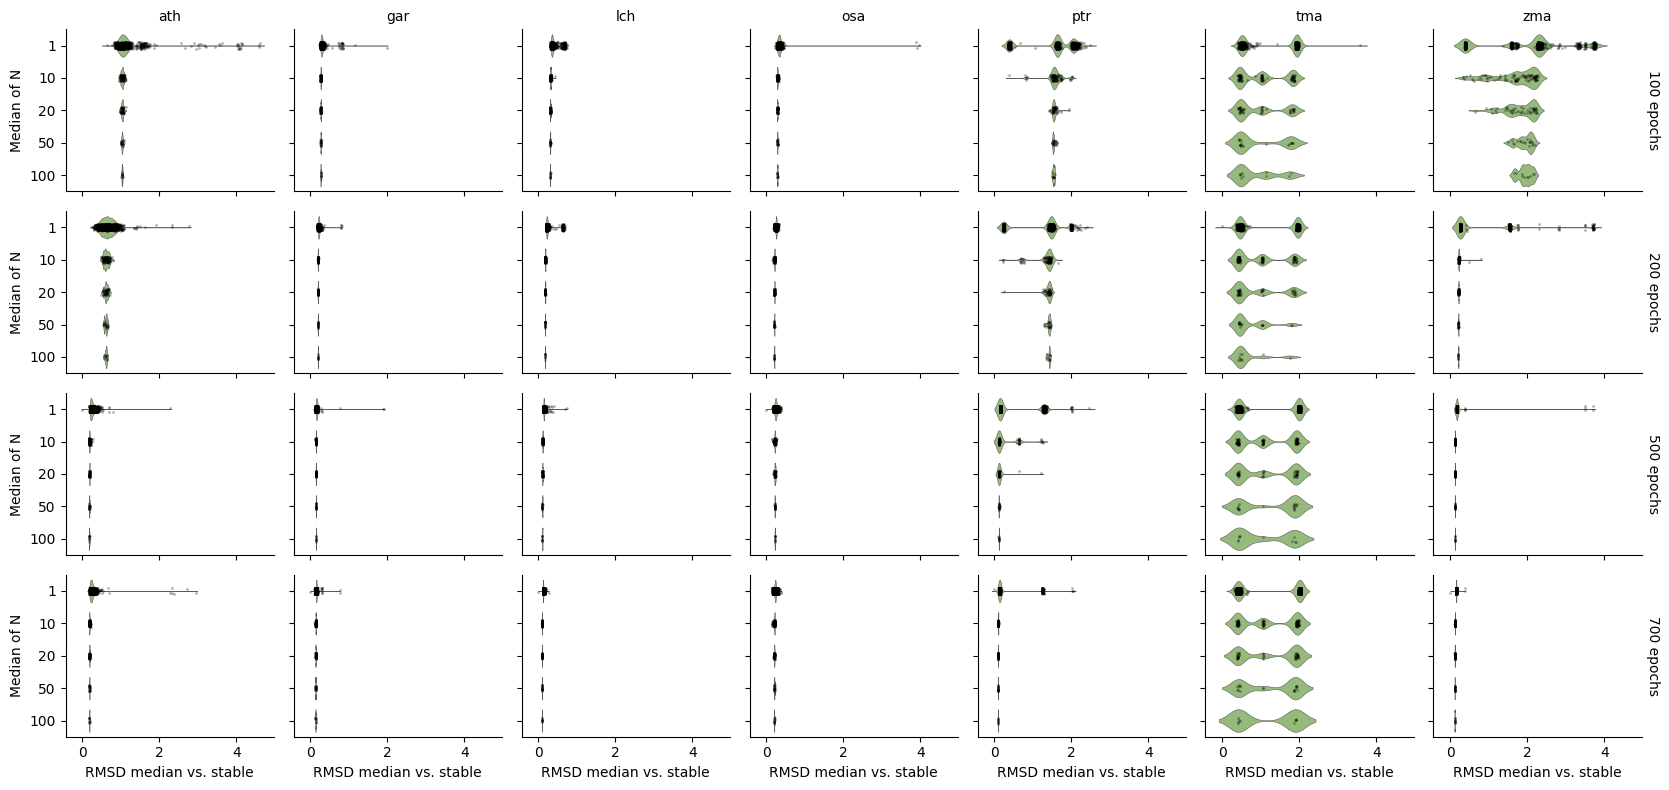

In [136]:
data = pd.concat(rmsd_df_list)
data = data.sort_values(by=["n_epochs", "aligned_n"])
data["n_epochs-n_median"] = data.apply(lambda x: f"{x.n_epochs} epochs x median-of-{x.aligned_n}", axis=1)
data["n_median"] = data["aligned_n"].astype(str)
g = sns.FacetGrid(
    data=data,
    col="sample",
    row="n_epochs",
    sharey=True,
    sharex=True,
    aspect=1.2,
    height=2,
    margin_titles=True
)
g.map_dataframe(
    sns.stripplot,
    x="rmsd",
    y="n_median",
    color="black",
    alpha=.3,
    s=2
)
g.map_dataframe(
    sns.violinplot,
    x="rmsd",
    y="n_median",
    color="#93c470",
    linewidth=0.4,
    fill=True,
    bw_adjust=.5,
    density_norm="width",
    width=.7,
    inner=None
)
g.set_axis_labels("RMSD median vs. stable", "Median of N")
g.set_titles(col_template="{col_name}", row_template="{row_name} epochs")
sns.despine()
g.savefig(paths.outdir() / "rmsd_median_vs_stable.svg")

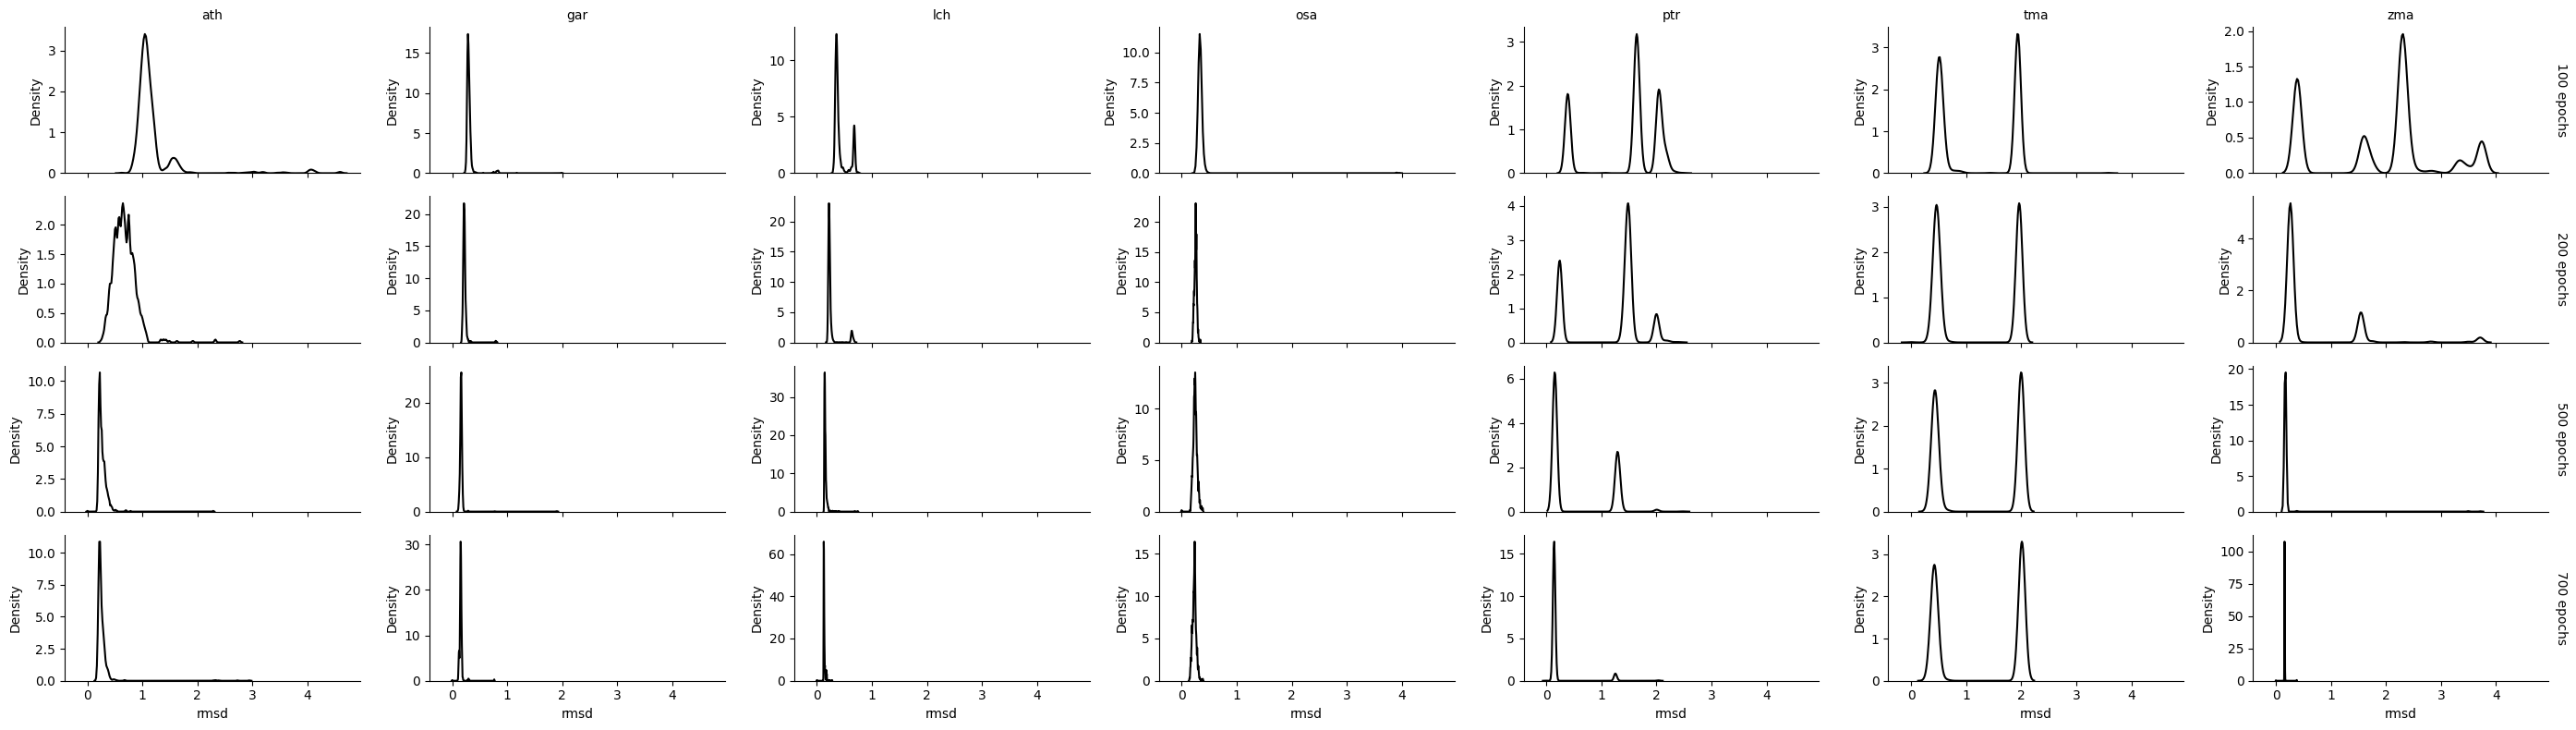

In [157]:
data = pd.concat(rmsd_df_list)
data = data.sort_values(by=["n_epochs", "aligned_n"])
data["n_epochs-n_median"] = data.apply(lambda x: f"{x.n_epochs} epochs x median-of-{x.aligned_n}", axis=1)
data["n_median"] = data["aligned_n"].astype(str)
g = sns.FacetGrid(
    data=data.query("n_median == '1'"),
    col="sample",
    row="n_epochs",
    sharey=False,
    sharex=True,
    aspect=2,
    height=2,
    margin_titles=True,
)
g.map_dataframe(
    sns.kdeplot,
    x="rmsd",
    color="black",
    bw_adjust=.3,
)
g.set_titles(col_template="{col_name}", row_template="{row_name} epochs")
sns.despine()
g.savefig(paths.outdir() / "rmsd_epochs_vs_stable.svg")

In [ ]:
data = pd.concat(rmsd_df_list)
data = data.sort_values(by=["n_epochs", "aligned_n"])
# data["sample-n_epochs"] = data.apply(lambda x: f"{x.sample}-{x.n_epochs} epochs", axis=1)
data["n_median"] = data["aligned_n"].astype(str)
fig, ax = plt.subplots(1, 1, figsize=(4*1.4, 3*1.4))
sns.stripplot(
    data=data.query("(n_median == '1')"),
    x="sample",
    y="rmsd",
    hue="n_epochs",
    dodge=True,
    s=2,
    alpha=0.5,
    ax=ax
)
ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.tight_layout()
fig.savefig(paths.outdir() / "rmsd_raw_vs_stable.svg")